# **Project: Weather Data Analysis Using NumPy, Pandas, and Matplotlib**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#here we import all the libaries we will use to analysis this dataset

# **Here we are importing our csv file from the system **

In [4]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv('weather_data_practice.csv')
df.head()

Saving weather_data_practice.csv to weather_data_practice.csv


,Date,Temperature,Humidity,Precipitation
0,2024-01-01,17.21,60.68,0.00
1,2024-01-02,14.71,72.90,1.17
2,2024-01-03,17.89,54.58,0.00
3,2024-01-04,21.43,74.84,5.15
4,2024-01-05,14.45,73.53,0.00


Here we are checkiing the DataTypes of the each columns values

In [5]:
df.dtypes

,0
Date,object
Temperature,float64
Humidity,float64
Precipitation,float64


In [56]:
df.shape  #This will help us to find the total rows and columns of our dataset

(731, 6)

In [7]:
df.info() # this will help us to see the null values,dtypes abd columns of our dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           734 non-null    object 
 1   Temperature    731 non-null    float64
 2   Humidity       731 non-null    float64
 3   Precipitation  731 non-null    float64
dtypes: float64(3), object(1)
memory usage: 23.1+ KB


In [8]:
df.isnull().sum() #This is used to find out the counts of null values

,0
Date,0
Temperature,3
Humidity,3
Precipitation,3


**Now we will fill up the null value by using the fillna()function of pandas**

In [11]:
df["Temperature"]=df["Temperature"].fillna(df["Temperature"].mean())

In [12]:
df["Humidity"]=df["Humidity"].fillna(df["Humidity"].mean())

In [13]:
df["Precipitation"]=df["Precipitation"].fillna(0)

In [14]:
df.isnull().sum()

,0
Date,0
Temperature,0
Humidity,0
Precipitation,0


**Now by using the duplicated()and drop_duplicates we will find and delete the duplicates value **

In [15]:
df.duplicated().sum()

np.int64(3)

In [16]:
df[df.duplicated()]

,Date,Temperature,Humidity,Precipitation
731,2024-02-20,21.51,55.89,0.00
732,2024-09-07,21.92,69.79,6.44
733,2025-05-15,36.82,48.72,0.00


In [19]:
df=df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["Date"]=pd.to_datetime(df["Date"])

In [22]:
df.dtypes

,0
Date,datetime64[ns]
Temperature,float64
Humidity,float64
Precipitation,float64


**Now we will find out the mean,median and standard deviation of temperature ,humidity and precipitation**

In [24]:
np.mean(df["Temperature"])

np.float64(24.946033131160394)

In [27]:
np.median(df["Temperature"])

np.float64(24.85)

In [28]:
np.std(df["Temperature"])

8.075864908744547

In [25]:
np.median(df["Humidity"])

np.float64(65.64)

In [29]:
np.mean(df["Humidity"])

np.float64(65.83452688351134)

In [30]:
np.std(df["Humidity"])

8.756342809429965

In [26]:
np.std(df["Precipitation"])

4.123593389797007

In [31]:
np.mean(df["Precipitation"])

np.float64(2.2081532147742817)

In [32]:
np.median(df["Precipitation"])

np.float64(0.0)

**Now by using the dt. function we will extract the month from the date column**

In [33]:
df["Month"]=df["Date"].dt.month

**Here is the average monthly temperature**

In [35]:
df.groupby("Month")["Temperature"].mean()

,Temperature
Month,
1,15.995806
2,20.118541
3,23.761774
4,29.128833
5,32.871613
6,34.640167
7,34.037152
8,30.523871
9,25.728333


## Here is the average monthly humidity

In [36]:
df.groupby("Month")["Humidity"].mean()

,Humidity
Month,
1,69.535000
2,68.669474
3,66.257469
4,62.941000
5,62.870806
6,63.029667
7,60.837581
8,63.184565
9,62.627884


**Here is the montly total preciptation**

In [38]:
df.groupby("Month")["Precipitation"].sum()

,Precipitation
Month,
1,126.07
2,103.48
3,135.29
4,169.84
5,116.72
6,169.81
7,121.24
8,143.27
9,108.74


**Here by using the isin() function ,by using the numpy select we will find out the season from the month**

In [40]:
from numpy.random import choice
conditions=[
    df["Month"].isin([1,2,12]),
    df["Month"].isin([3,4,5]),
    df["Month"].isin([6,7,8]),
    df["Month"].isin([9,10,11])
]

choices=["winter","spring","summer","autumn"]
df["Season"]=np.select(conditions,choices,default="Unknown")

**Here is the season wise average temperature**

In [42]:
df.groupby("Season")["Temperature"].mean()

,Temperature
Season,
autumn,21.143132
spring,28.581522
summer,33.049964
winter,16.835949


**Here is the season wise average humidity**

In [43]:
df.groupby("Season")["Humidity"].mean()

,Humidity
Season,
autumn,67.079467
spring,64.034854
summer,62.343223
winter,69.961381


**Here is the season wise total precipitation**

In [44]:
df.groupby("Season")["Precipitation"].sum()

,Precipitation
Season,
autumn,371.58
spring,421.85
summer,434.32
winter,386.41


**Now we will use charts visuals to visualize our findings **

In [45]:
monthly_temp=df.groupby("Month")["Temperature"].mean()

# **LINE CHART**

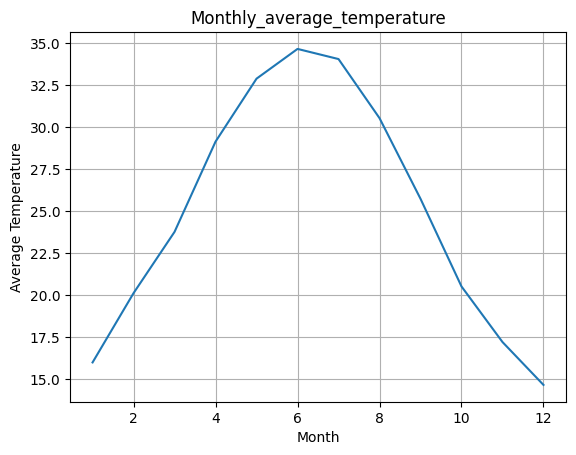

In [46]:
plt.plot(monthly_temp.index,monthly_temp.values)
plt.title("Monthly_average_temperature")
plt.xlabel("Month")
plt.ylabel("Average Temperature")
plt.grid()
plt.show()

# **BAR CHART**

In [47]:
monthly_precipitation=df.groupby("Month")["Precipitation"].sum()

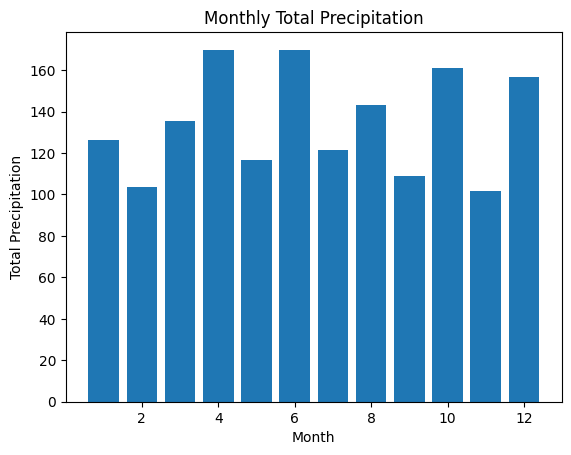

In [49]:
plt.bar(monthly_precipitation.index,monthly_precipitation.values)
plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Total Precipitation")
plt.show()

# **HISTOGRAM CHART**

Text(0.5, 1.0, 'Temperature Distribution')

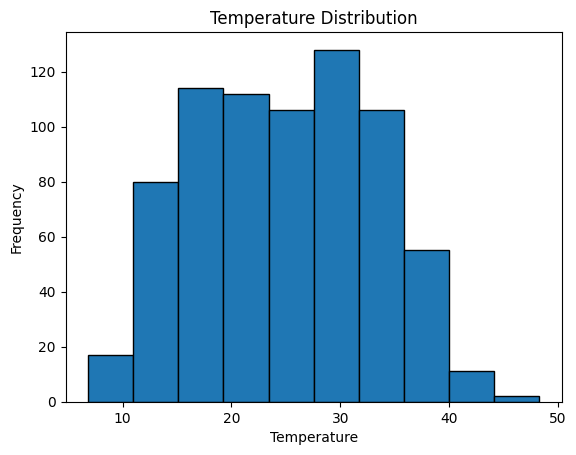

In [51]:
plt.hist(df["Temperature"],bins=10,edgecolor="black")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("Temperature Distribution")
plt.show()

# **Here is the some more findings like high_temperature and low_temperature days**

In [52]:
high_temp_days=df[df["Temperature"]>np.mean(df["Temperature"])]
high_temp_days.head()

,Date,Temperature,Humidity,Precipitation,Month,Season
31,2024-02-01,25.050000,85.46,15.97,2,winter
45,2024-02-15,24.953406,62.96,7.17,2,winter
54,2024-02-24,24.950000,73.67,3.72,2,winter
59,2024-02-29,25.530000,68.20,0.00,2,winter
64,2024-03-05,25.700000,73.11,0.00,3,spring


In [53]:
high_precipitation_days=df[df["Precipitation"]>np.mean(df["Precipitation"])]
high_precipitation_days.head()

,Date,Temperature,Humidity,Precipitation,Month,Season
3,2024-01-04,21.43,74.84,5.15,1,winter
10,2024-01-11,13.87,59.77,14.69,1,winter
17,2024-01-18,17.50,63.48,24.38,1,winter
20,2024-01-21,22.36,55.37,8.85,1,winter
21,2024-01-22,15.69,61.38,6.17,1,winter


In [55]:
low_temp_days=df[df["Temperature"]<np.mean(df["Temperature"])]
low_temp_days.head()

,Date,Temperature,Humidity,Precipitation,Month,Season
0,2024-01-01,17.21,60.68,0.00,1,winter
1,2024-01-02,14.71,72.90,1.17,1,winter
2,2024-01-03,17.89,54.58,0.00,1,winter
3,2024-01-04,21.43,74.84,5.15,1,winter
4,2024-01-05,14.45,73.53,0.00,1,winter
